In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"    

In [2]:
import sys
sys.path.append('../../utils/') 
from post_anal_plot import * 

### static LCI +  three GWP
- GWP100
- pGWP-fixed vs. dp-CO2 

In [3]:
wind  = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")
hydro = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/hydro_run-of-river_CN_US_staticLCI_threeGWP100.xlsx")
pv    = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/PV_CN_US_staticLCI_threeGWP100.xlsx")

In [3]:

def tidy(df, tech_label):
    parts = df["Activity"].str.split(", ", expand=True)
    out = df.copy()
    out["Technology"] = tech_label
    out["Country"]    = parts[3].str[:2]
    out["SSP"]        = parts[4]
    out["Year"]       = parts[5].astype(int)
    return out[["Technology", "Country", "SSP", "Year",
                "gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]]

all_df = pd.concat(
    [tidy(wind,  "Wind"),
     tidy(hydro, "Hydro"),
     tidy(pv,    "PV")],
    ignore_index=True,
)

# Keep only 2030 & 2050
df = all_df[all_df["Year"].isin([2030, 2050])].copy()

# long format over metrics
metric_cols = ["gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]
df_long = df.melt(
    id_vars=["Technology", "Country", "SSP", "Year"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)

df_long


,Technology,Country,SSP,Year,Metric,Score
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832
2,Wind,CN,SSP2-M,2030,gwp100,0.037723
3,Wind,CN,SSP2-M,2050,gwp100,0.031185
4,Wind,CN,SSP5-H,2030,gwp100,0.038734
...,...,...,...,...,...,...
103,PV,US,SSP1-VLLO,2050,pGWP100_dpCO2,0.006184
104,PV,US,SSP2-M,2030,pGWP100_dpCO2,0.020048
105,PV,US,SSP2-M,2050,pGWP100_dpCO2,0.012654
106,PV,US,SSP5-H,2030,pGWP100_dpCO2,0.020952


#### adding:  dpLCI + pGWP-fixedCO2

In [4]:

with open("../dp-LCI_output/dpLCI_pGWP-fixed_pickle/hydro_dp_results_MY2030_2050.pkl","rb") as f:
    hydro_dp = pickle.load(f)

with open("../dp-LCI_output/dpLCI_pGWP-fixed_pickle/PV_dp_results_MY2030_2050.pkl","rb") as f:
    pv_dp = pickle.load(f)

with open("../dp-LCI_output/dpLCI_pGWP-fixed_pickle/wind_dp_results_allMY.pkl","rb") as f:
    wind_dp = pickle.load(f)


# extract the new dp metrics and produce a DataFrame with exact columns:
# Activity, Technology, Country, SSP, Year, Metric, Score
# ONLY WANNA 2030 & 2050 as two MY:: 

def extract_from_dp_dict(dp_dict):
    rows = []

    # map activity string tech → tidy Technology label
    tech_map = {
        "wind": "Wind",
        "PV": "PV",
        "hydro": "Hydro",
    }

    #####   we need to convert all US-xx / CN-xx country code to just US/CN 
    def collapse_country(region):
        """Collapse ecoinvent/IAM region to CN or US."""
        if region.startswith("US"):
            return "US"
        if region.startswith("CN"):
            return "CN"
        # if you ever have other regions, either return as-is or map them too
        return region

    for act, metrics in dp_dict.items():
        parts = act.split(", ")

        raw_tech = parts[1]              # 'wind' / 'photovoltaic' / 'hydro'
        if raw_tech not in tech_map:
            print(row_tech)
            continue                     # skip unexpected techs

        tech        = tech_map[raw_tech]
        region      = parts[3]           # e.g. 'US-TRE', 'CN-NM'
        country     = collapse_country(region)
        ssp         = parts[4]
        year        = int(parts[5])

        # keep only 2030 & 2050
        if year not in (2030, 2050):
            continue

        for metric_name, value in metrics.items():
            rows.append(
                {
                    "Technology": tech,
                    "Country": country,   # NOW only 'US' or 'CN'
                    "SSP": ssp,
                    "Year": year,
                    "Metric": metric_name,
                    "Score": float(value),
                }
            )

    return pd.DataFrame(rows)



df_hydro_dp = extract_from_dp_dict(hydro_dp)
df_pv_dp    = extract_from_dp_dict(pv_dp)
df_wind_dp  = extract_from_dp_dict(wind_dp)

df_dp = pd.concat([df_hydro_dp, df_pv_dp, df_wind_dp], ignore_index=True)
print(len(df_dp)) # should be 72, so that 72/2(new metric) == 36
df_dp


72


,Technology,Country,SSP,Year,Metric,Score
0,Hydro,US,SSP5-H,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.004793
1,Hydro,US,SSP5-H,2030,"full dp-LCI, pGWP100-fixedCO2",0.004745
2,Hydro,US,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.004835
3,Hydro,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.004956
4,Hydro,CN,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.003733
...,...,...,...,...,...,...
67,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138
68,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229
69,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193
70,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520


In [5]:
#df_dp 
df_full = pd.concat([df_long, df_dp], ignore_index=True)
#df_full

#### now ranking 

In [6]:
# NOW recompute Rank with the two new metrics included
df_full["Rank"] = df_full.groupby(
    ["Country","SSP","Year","Metric"]
)["Score"].rank(method="dense", ascending=True)

df_full

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905,3.0
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832,3.0
2,Wind,CN,SSP2-M,2030,gwp100,0.037723,3.0
3,Wind,CN,SSP2-M,2050,gwp100,0.031185,3.0
4,Wind,CN,SSP5-H,2030,gwp100,0.038734,3.0
...,...,...,...,...,...,...,...
175,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138,3.0
176,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229,3.0
177,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193,3.0
178,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520,3.0


In [7]:
metric_rename = {
    "gwp100": "staticLCI + IPCC-GWP",
    "pGWP100_fixedCO2": "staticLCI + pGWP-fixedCO2",
    "pGWP100_dpCO2": "staticLCI + pGWP-dpCO2",
    "dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": "dyn-FG-LCI + pGWP-fixedCO2",
    "full dp-LCI, pGWP100-fixedCO2": "full dpLCI + pGWP-fixedCO2"
}


In [8]:
df_full["Metric"] = df_full["Metric"].replace(metric_rename)

In [9]:
df_full_sorted = df_full.sort_values([ "SSP","Year", "Country", "Technology"	]) 
df_full_sorted

,Technology,Country,SSP,Year,Metric,Score,Rank
12,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.004278,1.0
48,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.004835,1.0
84,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.004232,1.0
126,Hydro,CN,SSP1-VLLO,2030,dyn-FG-LCI + pGWP-fixedCO2,0.004835,1.0
127,Hydro,CN,SSP1-VLLO,2030,full dpLCI + pGWP-fixedCO2,0.004956,1.0
...,...,...,...,...,...,...,...
11,Wind,US,SSP5-H,2050,staticLCI + IPCC-GWP,0.019234,3.0
47,Wind,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.017215,3.0
83,Wind,US,SSP5-H,2050,staticLCI + pGWP-dpCO2,0.019006,3.0
168,Wind,US,SSP5-H,2050,dyn-FG-LCI + pGWP-fixedCO2,0.017215,3.0


In [10]:
df_full_sorted.to_excel("plot_rankshift_five_metrics.xlsx")

## plot 

In [3]:
df_full = pd.read_excel("plot_rankshift_whdpLCI.xlsx")
#df_full_sorted.head()

# remove the index column if present
#if "Unnamed: 0" in df_full.columns:
#    df_full = df_full.drop(columns=["Unnamed: 0"])


In [4]:
df_full

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.050523,3
1,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.051877,3
2,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.050841,3
3,Hydro,CN,SSP1-VLLO,2030,dyn-FG-LCI + pGWP-fixedCO2,0.051877,3
4,Hydro,CN,SSP1-VLLO,2030,full dpLCI + pGWP-fixedCO2,0.052092,3
...,...,...,...,...,...,...,...
175,Wind,US,SSP5-H,2050,staticLCI + IPCC-GWP,0.019235,2
176,Wind,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.023259,2
177,Wind,US,SSP5-H,2050,staticLCI + pGWP-dpCO2,0.018839,2
178,Wind,US,SSP5-H,2050,dyn-FG-LCI + pGWP-fixedCO2,0.023259,2


In [5]:
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    "dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2"
]

metric_labels = {m: m for m in metric_order}


### barplot function: to show real magnitude : 

- we put normalized 2050 scores (lower than the 2030) as basebar,
- then put the normalized 2030 scores on top as a stacked bar

### then normalization choice determines whether wind’s 2030 bar disappears (or becomes visually misleading) 
- now we normalize 2030 and 2050 separately, but then wind (2030 vs. 2050 diff) disappears


#### function for cross-region , same MY comp, goto ../dpLCI folder 

### function: one region two MY as subplots: 


#### funciton

In [15]:
# step2 (updated again): normalize EVERYTHING to ONE single bar:
# (baseline_tech, baseline_ssp, baseline_year, baseline_metric)
def plot_bar_oneregion_twoyears_norm_hydroBAU2030(
    df_full,
    years,
    country,
    metric_order,
    metric_labels,
    tech_colors,
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    technologies=("Hydro", "Wind", "PV"),   # enforce Hydro first
    bar_width=0.25,
    # ---- single-bar denominator controls ----
    baseline_tech="Hydro",
    baseline_ssp="SSP2-M",        # SSP2-45
    baseline_year=2030,
    baseline_metric=None,         # if None -> metric_order[0] ( 1st IPCC column)
    baseline_hatch="//",         # dots : "..",   
    baseline_hatch_lw=1.0,
):
    """
    Same REGION, two YEARS as columns.
    Bars ALWAYS ordered: Hydro -> Wind -> PV.

    Normalization:
      - Use ONE denominator for all bars across all panels and metrics:
          denom = Score(baseline_tech, baseline_ssp, baseline_year, baseline_metric)
      - If baseline_metric is None, uses metric_order[0] (i.e., the 1st column: staticLCI + IPCC-GWP).

    Baseline bar styling:
      - Apply hatch ONLY to that single baseline bar (NOT all baseline-tech bars).

    Annotations:
      - Annotate each bar with raw Score × 1000.

    Returns:
      fig, axes
    """
    df_r = df_full[df_full["Country"] == country].copy()

    if baseline_metric is None:
        baseline_metric = metric_order[0]

    # ---- get single denominator ----
    sub_base = df_r[
        (df_r["SSP"] == baseline_ssp) &
        (df_r["Year"] == baseline_year) &
        (df_r["Technology"] == baseline_tech) &
        (df_r["Metric"] == baseline_metric)
    ]["Score"]

    if len(sub_base) == 0 or pd.isna(sub_base.values[0]) or float(sub_base.values[0]) == 0:
        raise ValueError(
            "Baseline denominator not found or equals 0. "
            f"Check baseline_tech={baseline_tech}, baseline_ssp={baseline_ssp}, "
            f"baseline_year={baseline_year}, baseline_metric={baseline_metric}."
        )

    denom = float(sub_base.values[0])

    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(years),
        figsize=(10, 7),
        sharex=False,
        sharey=False
    )
    plt.subplots_adjust(hspace=0.28, wspace=0.18)

    for i, ssp in enumerate(ssps):
        for j, year in enumerate(years):
            ax = axes[i, j]
            sub = df_r[(df_r["SSP"] == ssp) & (df_r["Year"] == year)]

            ymax_here = 0.0

            for t_i, tech in enumerate(technologies):
                sub_t = sub[sub["Technology"] == tech]
                base_color = tech_colors[tech]

                for k, metric in enumerate(metric_order):
                    df_val = sub_t[sub_t["Metric"] == metric]["Score"]
                    if len(df_val) == 0:
                        continue

                    v = float(df_val.values[0])
                    normalized = v / denom * 100.0
                    raw_annot = v * 1000.0
                    xpos = k + (t_i - 1) * bar_width

                    # hatch ONLY the single baseline bar
                    is_single_baseline_bar = (
                        (tech == baseline_tech) and
                        (ssp == baseline_ssp) and
                        (year == baseline_year) and
                        (metric == baseline_metric)
                    )

                    bar_kwargs = dict(
                        x=xpos,
                        height=normalized,
                        width=bar_width,
                        color=base_color,
                        edgecolor="white",
                        linewidth=0.7
                    )
                    if is_single_baseline_bar and baseline_hatch:
                        bar_kwargs.update(dict(hatch=baseline_hatch, linewidth=baseline_hatch_lw))

                    ax.bar(**bar_kwargs)

                    ax.text(
                        xpos,
                        normalized * 0.55,
                        f"{raw_annot:.1f}",
                        ha="center",
                        va="center",
                        fontsize=14,
                        color="white"
                    )

                    ymax_here = max(ymax_here, normalized)

            # Titles & axes
            ax.set_title(f"{country}, {format_ssp(ssp)}, {year}", fontsize=13)

            ax.set_yticks([0, 25, 50, 75, 100, 125, 150, 200])
            ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y)}%"))

            if ymax_here > 0:
                ax.set_ylim(0, max(110, ymax_here * 1.15))

            if j == 0:
                ax.set_ylabel("Normalized impact (%)", fontsize=11)

            if i == len(ssps) - 1:
                ax.set_xticks(np.arange(len(metric_order)))
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=25,
                    ha="right",
                    fontsize=10
                )
            else:
                ax.set_xticks([])

            ax.grid(
                axis="y",
                linestyle="--",
                linewidth=0.9,
                alpha=0.8,
                color="0.35"
            )

    fig.suptitle(
        f"Technology GWP scores \n" #{country}
        f"(normalization: striped bar as reference), text lables indicate gram CO2e per kWh", #{baseline_tech}, {format_ssp(baseline_ssp)}, {baseline_year}, {metric_labels[baseline_metric]})",
        fontsize=16,
        y=0.96
    )
    plt.tight_layout(rect=[0, 0.07, 1, 0.98])

    # Legend (order fixed)
    handles = [
        plt.Rectangle(
            (0, 0), 1, 1,
            facecolor=tech_colors[t],
            edgecolor="black",
            linewidth=0.8
        )
        for t in technologies
    ]
    
    fig.legend(
        handles,
        technologies,
        loc="lower center",
        ncol=len(technologies),
        fontsize=12,
        frameon=True,
        bbox_to_anchor=(0.5, 0)
    )

    return fig, axes

#### plot one region, two years

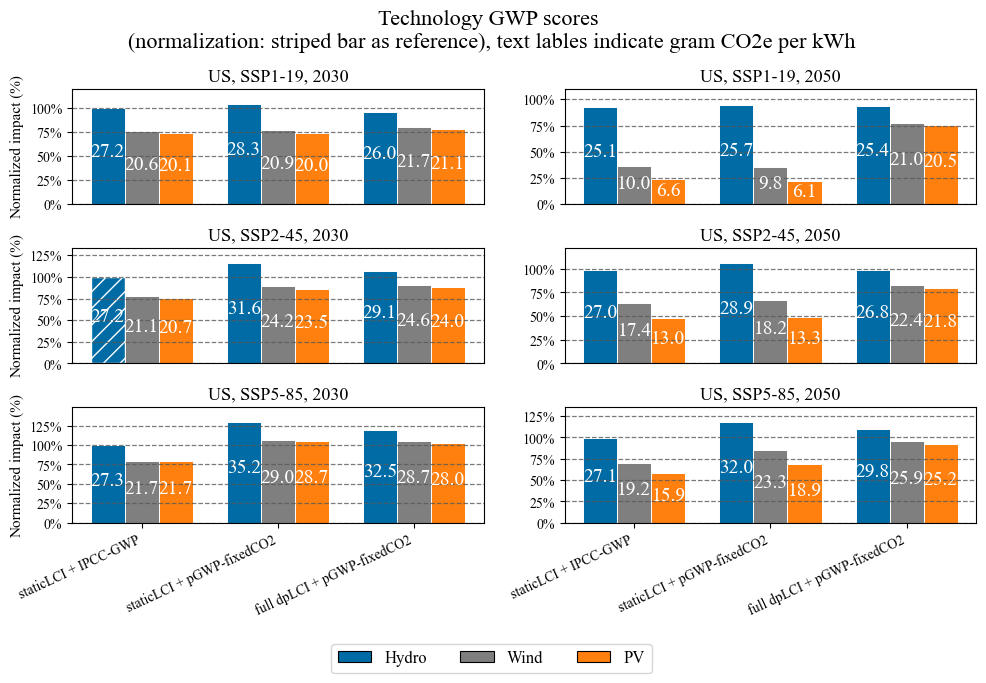

In [16]:
# let's filter out only three metric (caz we not suggest using pGWP100-dpCO2 anyways)
metric_order = [
    "staticLCI + IPCC-GWP",
    #"staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    #"dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2"
]

tech_colors = {"PV":"#FF800E","Wind": "#7F7F7F" ,"Hydro": "#006BA4"}


df_full_filt = df_full[df_full["Metric"].isin(metric_order)].copy()


fig, axes = plot_bar_oneregion_twoyears_norm_hydroBAU2030(
    df_full=df_full_filt,
    years=(2030, 2050),
    country="US",
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
    baseline_hatch="//"
)

fig.savefig("fig_output/barplot_US_comp_threeTech.png", dpi=600, bbox_inches="tight")

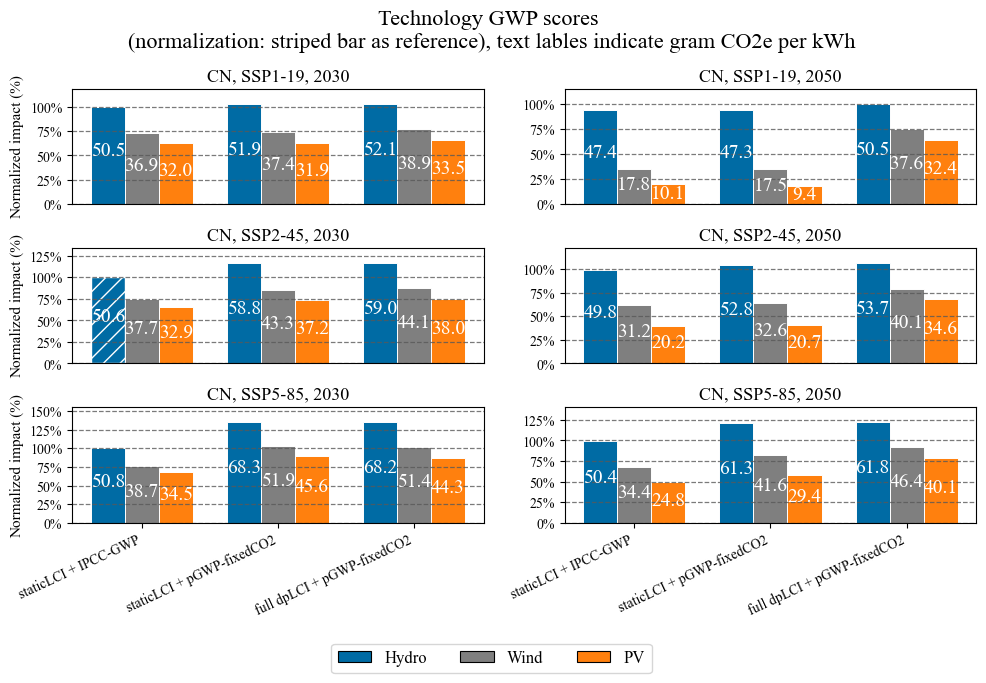

In [17]:
metric_order = [
    "staticLCI + IPCC-GWP",
    #"staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    #"dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2"
]

tech_colors = {"PV":"#FF800E","Wind": "#7F7F7F" ,"Hydro": "#006BA4"}


df_full_filt = df_full[df_full["Metric"].isin(metric_order)].copy()


fig, axes = plot_bar_oneregion_twoyears_norm_hydroBAU2030(
    df_full=df_full_filt,
    years=(2030, 2050),
    country="CN",
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
)


fig.savefig("fig_output/barplot_CN_comp_threeTech.png", dpi=600, bbox_inches="tight")